In [2]:
import torch
import torchvision.models as models

# Load pretrained ResNet18 — weights learned from 1.2M ImageNet images
model = models.resnet18(pretrained=True)
model.eval()  # Set to evaluation mode (disables dropout, etc.)

print("=== ResNet18 Architecture ===\n")
for name, module in model.named_children():
    print(f"[{name}]  →  {module.__class__.__name__}")

print("\n=== Layer 1 Detail ===")
print(model.layer1)

print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

=== ResNet18 Architecture ===

[conv1]  →  Conv2d
[bn1]  →  BatchNorm2d
[relu]  →  ReLU
[maxpool]  →  MaxPool2d
[layer1]  →  Sequential
[layer2]  →  Sequential
[layer3]  →  Sequential
[layer4]  →  Sequential
[avgpool]  →  AdaptiveAvgPool2d
[fc]  →  Linear

=== Layer 1 Detail ===
Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (1): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1,

Layer 1 output shape: torch.Size([64, 56, 56])  (channels × height × width)


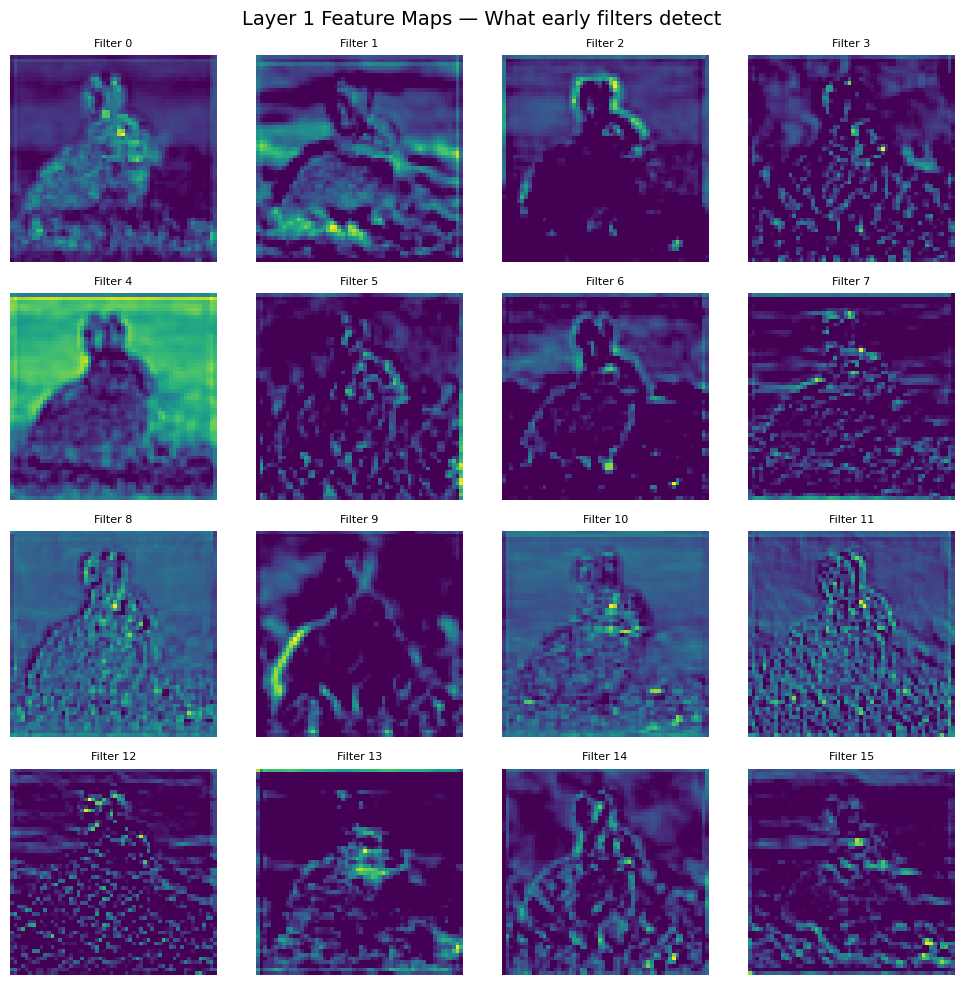

Saved: layer1_features.png


In [3]:
import torch
import torchvision.models as models
import torchvision.transforms as T
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

# --- Load model and register a hook on the first conv layer ---
model = models.resnet18(pretrained=True)
model.eval()

feature_maps = {}

def save_output(name):
    def hook(module, input, output):
        feature_maps[name] = output.detach()
    return hook

model.layer1.register_forward_hook(save_output("layer1"))

# --- Load and preprocess an image ---
# Wikimedia requires a User-Agent header or it returns a non-image error page
url = "https://upload.wikimedia.org/wikipedia/commons/3/37/Oryctolagus_cuniculus_Tasmania_2.jpg"
headers = {"User-Agent": "Mozilla/5.0 (cv-lab-student-project)"}
img = Image.open(BytesIO(requests.get(url, headers=headers).content)).convert("RGB")

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
tensor = transform(img).unsqueeze(0)  # Add batch dimension

# --- Forward pass ---
with torch.no_grad():
    _ = model(tensor)

# --- Visualize first 16 feature maps from layer1 ---
fmaps = feature_maps["layer1"][0]  # Shape: [64, 56, 56]
print(f"Layer 1 output shape: {fmaps.shape}  (channels × height × width)")

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("Layer 1 Feature Maps — What early filters detect", fontsize=14)

for i, ax in enumerate(axes.flat):
    ax.imshow(fmaps[i].numpy(), cmap="viridis")
    ax.set_title(f"Filter {i}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.savefig("layer1_features.png", dpi=100)
plt.show()
print("Saved: layer1_features.png")

/home/bieljo/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/bieljo/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Layer 1 feature map shape: torch.Size([1, 64, 56, 56])
Layer 4 feature map shape: torch.Size([1, 512, 7, 7])


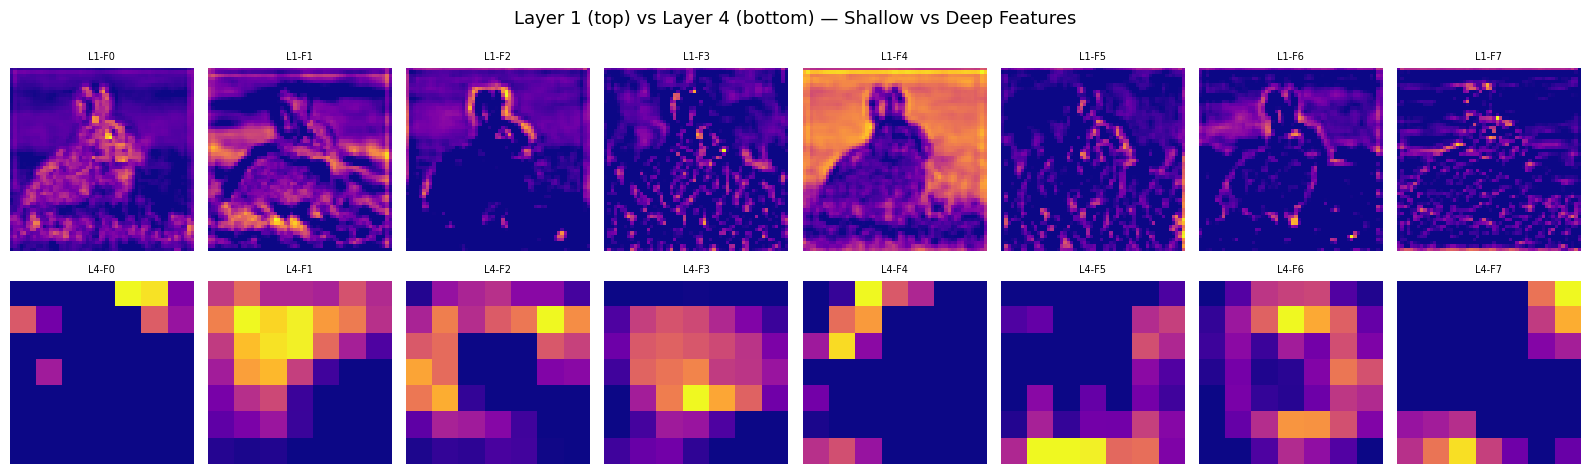

In [1]:
import torch
import torchvision.models as models
import torchvision.transforms as T
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

model = models.resnet18(pretrained=True)
model.eval()

maps = {}

for layer_name in ["layer1", "layer4"]:
    getattr(model, layer_name).register_forward_hook(
        lambda m, i, o, n=layer_name: maps.update({n: o.detach()})
    )

url = "https://upload.wikimedia.org/wikipedia/commons/3/37/Oryctolagus_cuniculus_Tasmania_2.jpg"
img = Image.open(BytesIO(requests.get(url, headers={"User-Agent": "Mozilla/5.0 (cv-lab-student-project)"}).content)).convert("RGB")
tensor = T.Compose([
    T.Resize((224, 224)), T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])(img).unsqueeze(0)

with torch.no_grad():
    _ = model(tensor)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle("Layer 1 (top) vs Layer 4 (bottom) — Shallow vs Deep Features", fontsize=13)

for i in range(8):
    axes[0, i].imshow(maps["layer1"][0][i].numpy(), cmap="plasma")
    axes[0, i].set_title(f"L1-F{i}", fontsize=7)
    axes[0, i].axis("off")

    axes[1, i].imshow(maps["layer4"][0][i].numpy(), cmap="plasma")
    axes[1, i].set_title(f"L4-F{i}", fontsize=7)
    axes[1, i].axis("off")

print(f"Layer 1 feature map shape: {maps['layer1'].shape}")
print(f"Layer 4 feature map shape: {maps['layer4'].shape}")

plt.tight_layout()
plt.savefig("layer_comparison.png", dpi=100)
plt.show()

Predicted class: hare  (index 331)
Confidence: 81.01%


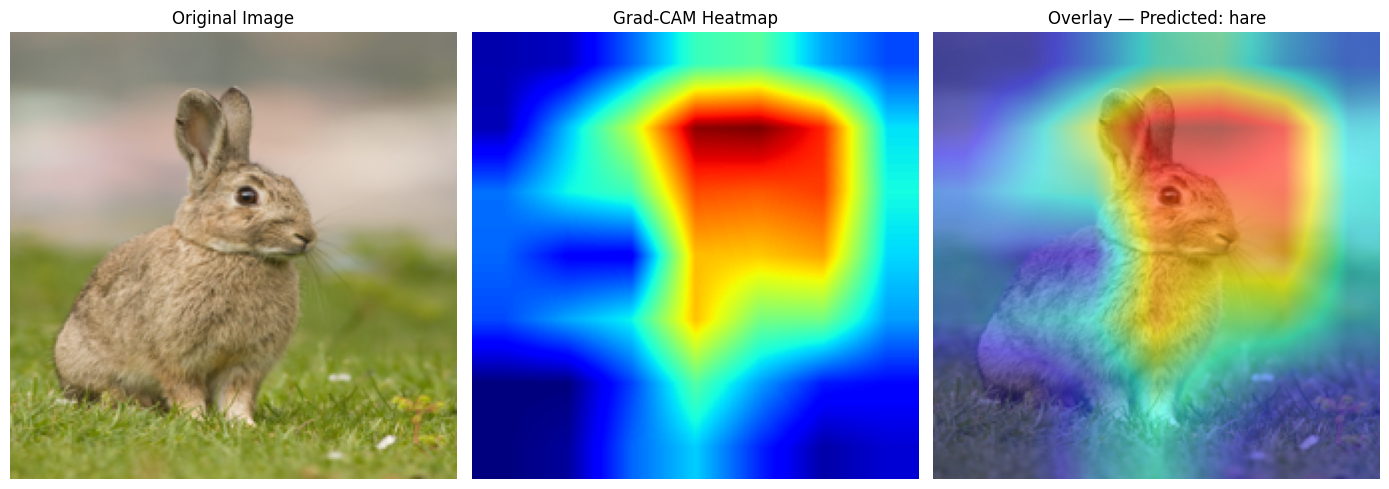

In [13]:
import torch
import torchvision.models as models
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from PIL import Image
import requests
from io import BytesIO

# Load model
model = models.resnet18(pretrained=True)
model.eval()

# Target the last convolutional layer — richest spatial features
target_layers = [model.layer4[-1]]

# Load image
url = "https://upload.wikimedia.org/wikipedia/commons/3/37/Oryctolagus_cuniculus_Tasmania_2.jpg"
img_pil = Image.open(BytesIO(requests.get(url, headers={"User-Agent": "Mozilla/5.0 (cv-lab-student-project)"}).content)).convert("RGB").resize((224, 224))
img_np = np.array(img_pil) / 255.0  # Normalized for overlay

tensor = T.Compose([
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])(img_pil).unsqueeze(0)

# Run Grad-CAM
cam = GradCAM(model=model, target_layers=target_layers)

from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

grayscale_cam = cam(input_tensor=tensor, targets=[ClassifierOutputTarget(94)])  # targets=None → top predicted class

# grayscale_cam = cam(input_tensor=tensor, targets=None)  # targets=None → top predicted class

# Get predicted class name
with torch.no_grad():
    output = model(tensor)
    pred_idx = output.argmax(1).item()

# Load ImageNet class labels
labels_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
labels = requests.get(labels_url, headers={"User-Agent": "Mozilla/5.0 (cv-lab-student-project)"}).text.strip().split("\n")
print(f"Predicted class: {labels[pred_idx]}  (index {pred_idx})")
print(f"Confidence: {torch.softmax(output, dim=1)[0][pred_idx].item():.2%}")

# Overlay heatmap
visualization = show_cam_on_image(img_np.astype(np.float32), grayscale_cam[0], use_rgb=True)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(img_pil); axes[0].set_title("Original Image"); axes[0].axis("off")
axes[1].imshow(grayscale_cam[0], cmap="jet"); axes[1].set_title("Grad-CAM Heatmap"); axes[1].axis("off")
axes[2].imshow(visualization); axes[2].set_title(f"Overlay — Predicted: {labels[pred_idx]}"); axes[2].axis("off")

plt.tight_layout()
plt.savefig("gradcam.png", dpi=100)
plt.show()

Rabbit on grass → Predicted: hare  (81.0%)
Pier → Predicted: hare  (43.0%)


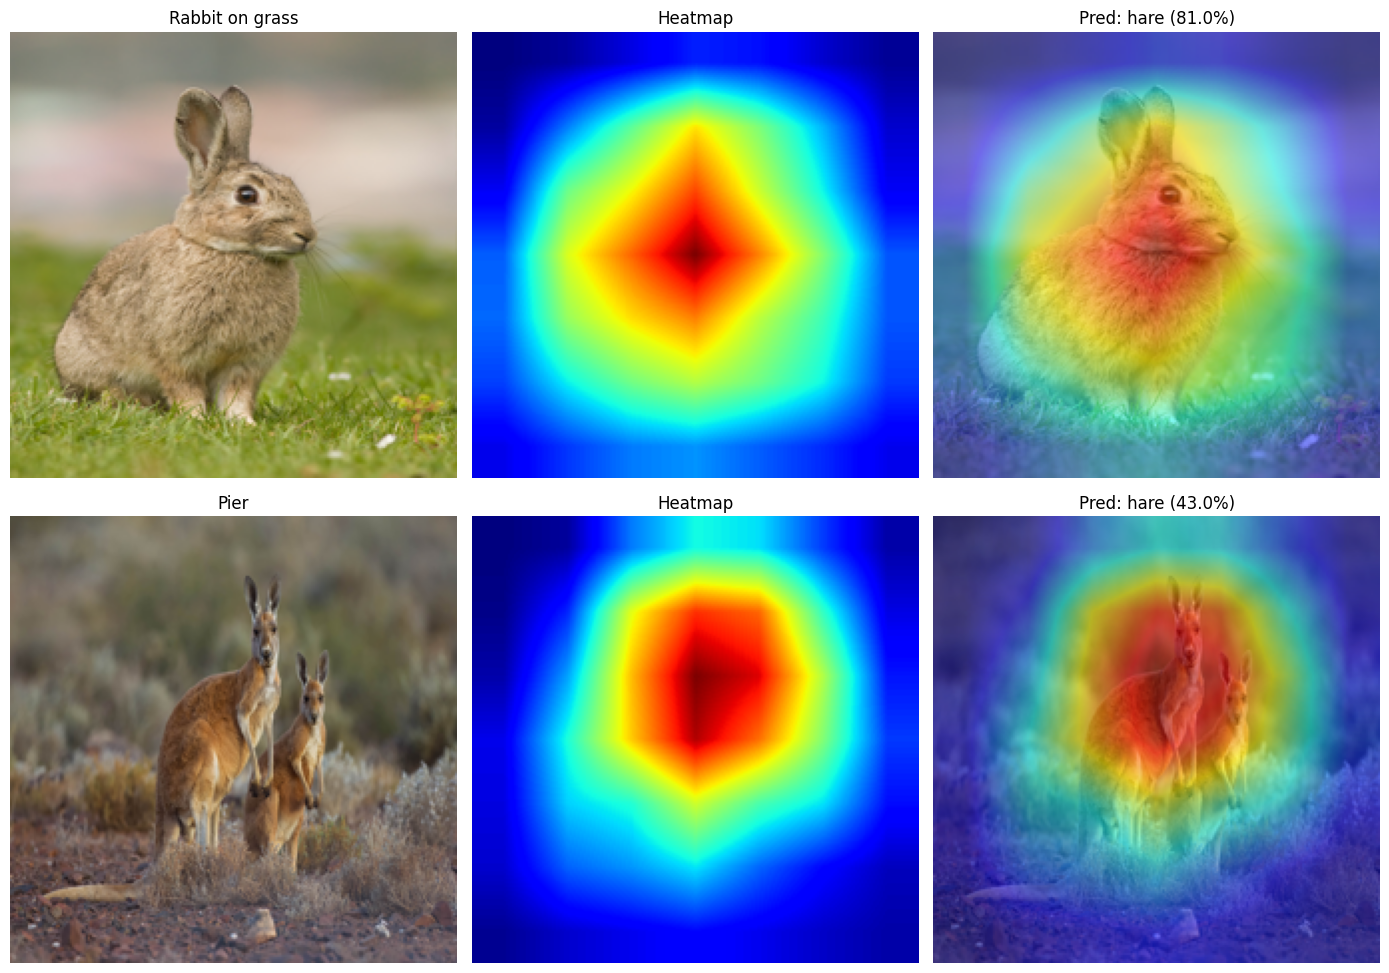

In [9]:
import torch
import torchvision.models as models
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from PIL import Image
import requests
from io import BytesIO

model = models.resnet18(pretrained=True)
model.eval()
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

headers = {"User-Agent": "Mozilla/5.0 (cv-lab-student-project)"}
labels = requests.get(
    "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt", headers=headers
).text.strip().split("\n")

# Try different images — swap URLs to explore
test_images = {
    "Rabbit on grass": "https://upload.wikimedia.org/wikipedia/commons/3/37/Oryctolagus_cuniculus_Tasmania_2.jpg",
    "Pier":  "https://upload.wikimedia.org/wikipedia/commons/5/5f/Red_Kangaroos_at_Sturt_National_Park_NSW.jpg",
}

transform = T.Compose([
    T.Resize((224, 224)), T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

fig, axes = plt.subplots(len(test_images), 3, figsize=(14, 5 * len(test_images)))

for row, (label, url) in enumerate(test_images.items()):
    img_pil = Image.open(BytesIO(requests.get(url, headers={"User-Agent": "Mozilla/5.0 (cv-lab-student-project)"}).content)).convert("RGB").resize((224, 224))
    img_np = np.array(img_pil) / 255.0
    tensor = transform(img_pil).unsqueeze(0)

    grayscale_cam = cam(input_tensor=tensor, targets=None)

    with torch.no_grad():
        output = model(tensor)
    pred_idx = output.argmax(1).item()
    confidence = torch.softmax(output, dim=1)[0][pred_idx].item()

    overlay = show_cam_on_image(img_np.astype(np.float32), grayscale_cam[0], use_rgb=True)

    axes[row, 0].imshow(img_pil); axes[row, 0].set_title(label); axes[row, 0].axis("off")
    axes[row, 1].imshow(grayscale_cam[0], cmap="jet"); axes[row, 1].set_title("Heatmap"); axes[row, 1].axis("off")
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(f"Pred: {labels[pred_idx]} ({confidence:.1%})")
    axes[row, 2].axis("off")

    print(f"{label} → Predicted: {labels[pred_idx]}  ({confidence:.1%})")

plt.tight_layout()
plt.savefig("gradcam_multi.png", dpi=100)
plt.show()

Original prediction: hare  (81.0%)
Adversarial prediction: wood rabbit  (99.9%)
L-inf perturbation norm: 0.0200


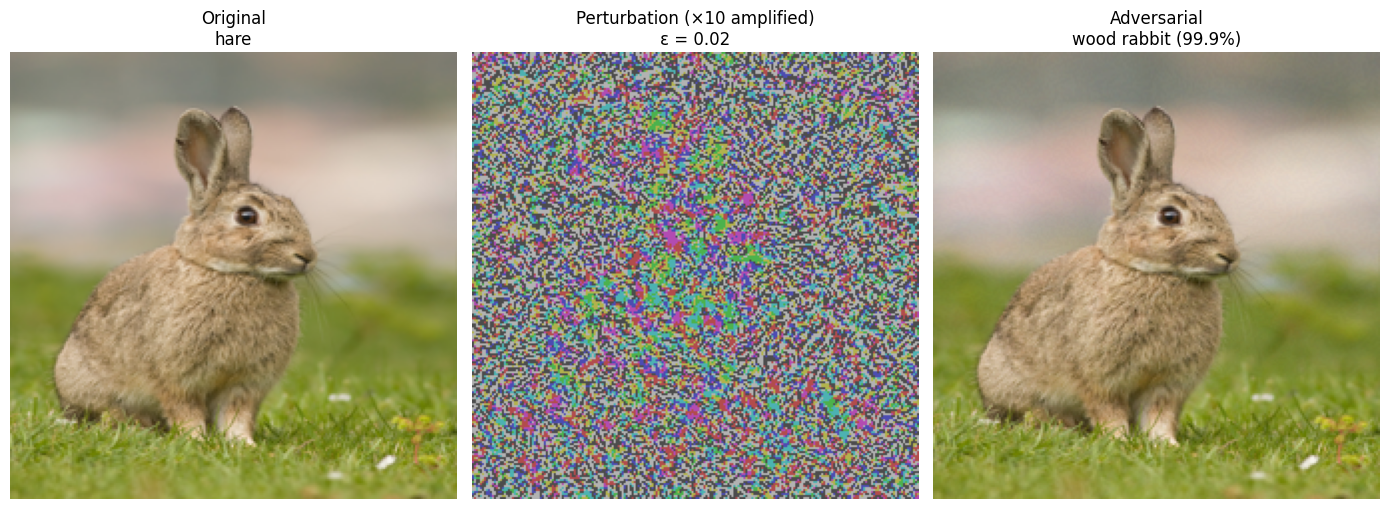

In [11]:
import torch
import torchvision.models as models
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

model = models.resnet18(pretrained=True)
model.eval()

labels = requests.get(
    "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
).text.strip().split("\n")

# Load image
url = "https://upload.wikimedia.org/wikipedia/commons/3/37/Oryctolagus_cuniculus_Tasmania_2.jpg"
img_pil = Image.open(BytesIO(requests.get(url, headers={"User-Agent": "Mozilla/5.0 (cv-lab-student-project)"}).content)).convert("RGB").resize((224, 224))

transform = T.Compose([
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

tensor = transform(img_pil).unsqueeze(0).requires_grad_(True)  # Enable gradients on INPUT

# --- Forward pass: get original prediction ---
output = model(tensor)
orig_class = output.argmax(1).item()
print(f"Original prediction: {labels[orig_class]}  ({torch.softmax(output,1)[0][orig_class].item():.1%})")

# --- FGSM Attack ---
epsilon = 0.02  # Try 0.01, 0.05, 0.1 and observe changes
loss = torch.nn.CrossEntropyLoss()(output, torch.tensor([orig_class]))
loss.backward()  # Compute gradients with respect to INPUT pixels

# Perturb: move each pixel in the direction that increases loss
perturbation = epsilon * tensor.grad.sign()
adversarial = tensor + perturbation

# --- Classify adversarial image ---
with torch.no_grad():
    adv_output = model(adversarial)
adv_class = adv_output.argmax(1).item()
adv_conf = torch.softmax(adv_output, 1)[0][adv_class].item()
print(f"Adversarial prediction: {labels[adv_class]}  ({adv_conf:.1%})")
print(f"L-inf perturbation norm: {perturbation.abs().max().item():.4f}")

# --- Visualize ---
def to_displayable(t):
    """Denormalize tensor back to [0,1] for display"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (t.squeeze() * std + mean).clamp(0, 1).permute(1,2,0).detach().numpy()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(to_displayable(tensor)); axes[0].set_title(f"Original\n{labels[orig_class]}"); axes[0].axis("off")

# Amplify perturbation 10× for visibility
perturb_vis = (perturbation.squeeze().permute(1,2,0).detach().numpy() * 10 + 0.5).clip(0,1)
axes[1].imshow(perturb_vis); axes[1].set_title(f"Perturbation (×10 amplified)\nε = {epsilon}"); axes[1].axis("off")

axes[2].imshow(to_displayable(adversarial)); axes[2].set_title(f"Adversarial\n{labels[adv_class]} ({adv_conf:.1%})"); axes[2].axis("off")

plt.tight_layout()
plt.savefig("adversarial.png", dpi=100)
plt.show()

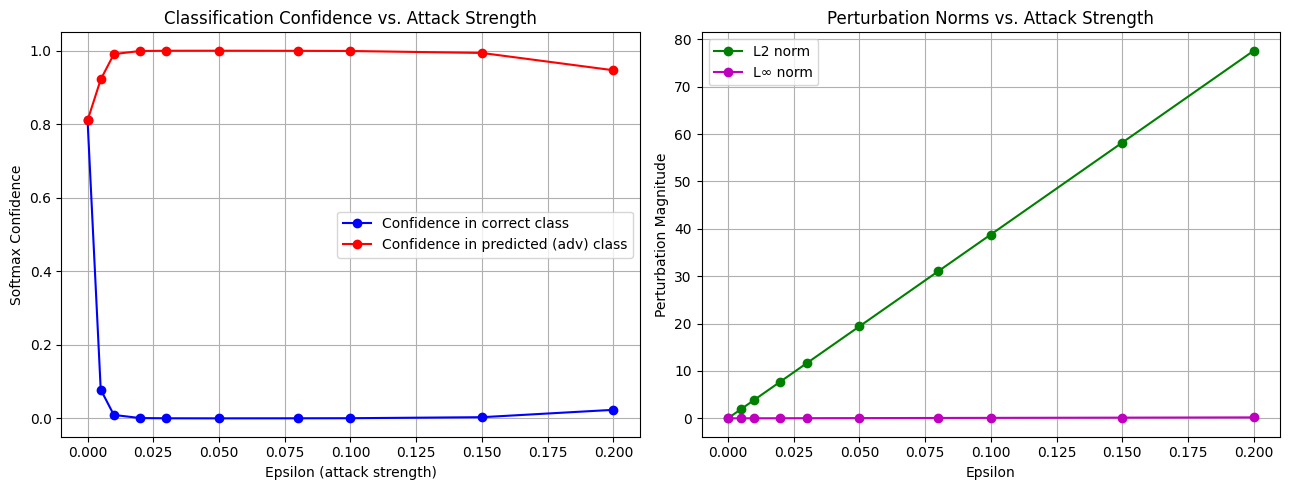

Original class confidence at ε=0: 81.0%
Confidence drops below 50% at ε ≈ 0.005


In [14]:
import torch
import torchvision.models as models
import torchvision.transforms as T
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

model = models.resnet18(pretrained=True)
model.eval()

url = "https://upload.wikimedia.org/wikipedia/commons/3/37/Oryctolagus_cuniculus_Tasmania_2.jpg"
img_pil = Image.open(BytesIO(requests.get(url, headers={"User-Agent": "Mozilla/5.0 (cv-lab-student-project)"}).content)).convert("RGB").resize((224, 224))
transform = T.Compose([
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
tensor = transform(img_pil).unsqueeze(0)

# Get original class
with torch.no_grad():
    orig_output = model(tensor)
orig_class = orig_output.argmax(1).item()

epsilons = [0.0, 0.005, 0.01, 0.02, 0.03, 0.05, 0.08, 0.1, 0.15, 0.2]
correct_confs, adv_confs, l2_norms, linf_norms = [], [], [], []

for eps in epsilons:
    t = tensor.clone().requires_grad_(True)
    out = model(t)
    loss = torch.nn.CrossEntropyLoss()(out, torch.tensor([orig_class]))
    loss.backward()

    with torch.no_grad():
        perturb = eps * t.grad.sign()
        adv = t + perturb
        adv_out = model(adv)
        probs = torch.softmax(adv_out, 1)[0]

        correct_confs.append(probs[orig_class].item())
        adv_confs.append(probs.max().item())
        l2_norms.append(perturb.norm(p=2).item())
        linf_norms.append(perturb.abs().max().item())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(epsilons, correct_confs, "b-o", label="Confidence in correct class")
axes[0].plot(epsilons, adv_confs,    "r-o", label="Confidence in predicted (adv) class")
axes[0].set_xlabel("Epsilon (attack strength)")
axes[0].set_ylabel("Softmax Confidence")
axes[0].set_title("Classification Confidence vs. Attack Strength")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epsilons, l2_norms,   "g-o", label="L2 norm")
axes[1].plot(epsilons, linf_norms, "m-o", label="L∞ norm")
axes[1].set_xlabel("Epsilon")
axes[1].set_ylabel("Perturbation Magnitude")
axes[1].set_title("Perturbation Norms vs. Attack Strength")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig("robustness_curves.png", dpi=100)
plt.show()

print(f"Original class confidence at ε=0: {correct_confs[0]:.1%}")
print(f"Confidence drops below 50% at ε ≈ {epsilons[[c < 0.5 for c in correct_confs].index(True)]}")